In [3]:
import sys
sys.path.insert(0, str("/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro"))

In [4]:
import os
import numpy as np
import h5py
from tqdm import tqdm
import pandas as pd
from pathlib import Path, PurePath
from Bio import SeqIO

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import sinabro_v2 as snbr

/home/ceel/miniconda3/envs/seta_demo/lib/python3.9/site-packages/Bio/codonalign/__init__.py:23: BiopythonExperimentalWarning: Bio.codonalign is an experimental module which may undergo significant changes prior to its future official release.
  warnings.warn(


In [3]:
import h5py

def tree_h5(file_path, max_depth=3):
    """
    Print HDF5 file structure in a tree-like format.
    
    Parameters:
    - file_path: path to the HDF5 file
    - max_depth: maximum depth to traverse (default: 3)
    """
    def recurse(name, obj, prefix='', depth=1, last=False):
        # choose branch connector
        connector = '└── ' if last else '├── '
        print(prefix + connector + name)
        
        # if this is a group and we haven't reached max depth, recurse into children
        if isinstance(obj, h5py.Group) and depth < max_depth:
            children = list(obj.items())
            for i, (child_name, child_obj) in enumerate(children):
                is_last = (i == len(children) - 1)
                # extend prefix: if this was the last child, add spaces; otherwise add vertical bar
                new_prefix = prefix + ('    ' if last else '│   ')
                recurse(child_name, child_obj, new_prefix, depth + 1, is_last)

    # open file and start recursion
    with h5py.File(file_path, 'r') as f:
        print(file_path)
        root_items = list(f.items())
        for i, (name, obj) in enumerate(root_items):
            is_last = (i == len(root_items) - 1)
            recurse(name, obj, prefix='', depth=1, last=is_last)


In [5]:
tree_h5("/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/lrho_sbs2.h5")

/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/lrho_sbs2.h5
└── lrho


In [4]:
filename = "/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/lrho_sbs2.h5"
with h5py.File(filename, 'r') as f:
    print(f["/lrho"][:])
    lrhos = f["/lrho"][:]

[4.056 4.554 5.712 ... 2.771 3.274 2.56 ]


In [5]:
data_path = '/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/'
genes_fasta_file = Path(PurePath(data_path, "gencode.v40.pc_transcripts.nopary.cdsplus.longest.fa"))

seq_records = list(SeqIO.parse(genes_fasta_file, "fasta"))

In [6]:
transcript_names = []
for seq_record in seq_records:
    transcript_name = seq_record.id.split("|")[4]
    transcript_names.append(transcript_name)
    

In [14]:
len(lrhos)

3740

In [7]:
rums_nonsyn_file = Path(PurePath(data_path, "all_gencode_rums_profile.csv")) 
rums_nonsyn = pd.read_csv(rums_nonsyn_file, header=0)

rums_nonsyn

,Transcript,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,...,SBS86,SBS87,SBS88,SBS89,SBS90,SBS91,SBS92,SBS93,SBS94,SBS95
0,A1BG-201,0.578,1.176,0.358,0.390,0.467,0.653,0.663,0.615,0.253,...,0.293,0.510,0.229,0.391,0.135,0.576,0.512,0.302,0.419,0.403
1,A1CF-201,0.381,0.504,0.311,0.305,0.383,0.341,0.423,0.478,0.225,...,0.191,0.301,0.215,0.341,0.209,0.324,0.397,0.271,0.327,0.278
2,A1CF-202,0.388,0.515,0.324,0.293,0.370,0.352,0.375,0.432,0.232,...,0.171,0.285,0.218,0.309,0.221,0.318,0.411,0.291,0.321,0.279
3,A1CF-203,0.313,0.537,0.288,0.312,0.357,0.332,0.377,0.378,0.221,...,0.147,0.318,0.201,0.305,0.232,0.341,0.389,0.289,0.314,0.263
4,A1CF-204,0.340,0.510,0.286,0.283,0.356,0.317,0.380,0.402,0.217,...,0.179,0.325,0.197,0.326,0.208,0.285,0.383,0.269,0.310,0.272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73209,ZYX-201,0.640,0.778,0.331,0.350,0.344,0.559,0.488,0.530,0.256,...,0.220,0.437,0.254,0.314,0.200,0.330,0.457,0.335,0.394,0.308
73210,ZYX-203,0.529,0.825,0.346,0.315,0.401,0.514,0.571,0.651,0.246,...,0.215,0.367,0.231,0.365,0.198,0.327,0.474,0.265,0.411,0.306
73211,ZZEF1-201,0.519,0.748,0.333,0.338,0.377,0.522,0.563,0.609,0.223,...,0.216,0.371,0.239,0.331,0.188,0.383,0.417,0.283,0.381,0.290
73212,ZZZ3-201,0.207,0.288,0.237,0.196,0.370,0.431,0.255,0.312,0.148,...,0.091,0.268,0.306,0.275,0.175,0.148,0.369,0.229,0.280,0.168


In [19]:
sbs2_lrho_ns = rums_nonsyn['SBS2'].values

In [16]:
sbs2_lrho_ns = rums_nonsyn.set_index('Transcript').loc[transcript_names[:len(lrhos)], 'SBS2'].to_numpy()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

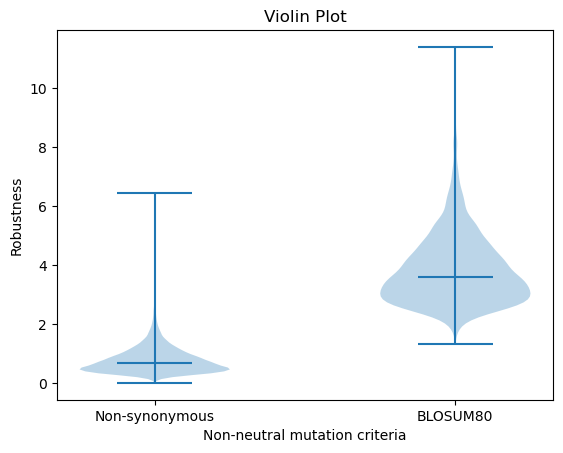

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

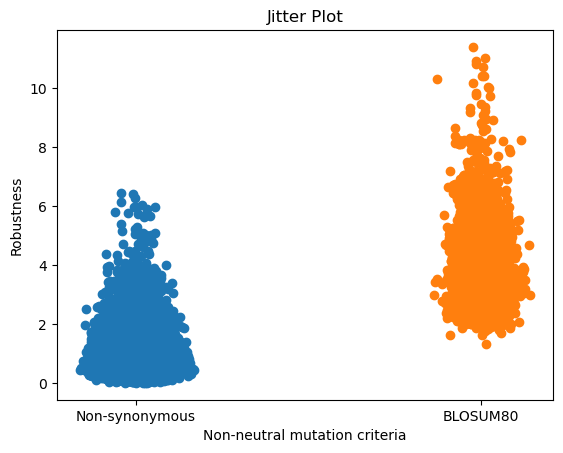

In [20]:
# Pack into list for plotting
data = [sbs2_lrho_ns, lrhos]
labels = ['Non-synonymous', 'BLOSUM80']  # x축 레이블

# ---- Violin Plot ----
plt.figure()
plt.violinplot(data, showmeans=False, showmedians=True)
plt.xticks([1, 2], labels)
plt.xlabel('Non-neutral mutation criteria')
plt.ylabel('Robustness')
plt.title('Violin Plot')
plt.show()

# ---- Jitter Plot ----
plt.figure()
# Generate x-coordinates with jitter around 1 and 2
x1 = np.random.normal(1, 0.04, size=len(sbs2_lrho_ns))
x2 = np.random.normal(2, 0.04, size=len(lrhos))

plt.scatter(x1, sbs2_lrho_ns)
plt.scatter(x2, lrhos)
plt.xticks([1, 2], labels)
plt.xlabel('Non-neutral mutation criteria')
plt.ylabel('Robustness')
plt.title('Jitter Plot')
plt.show()

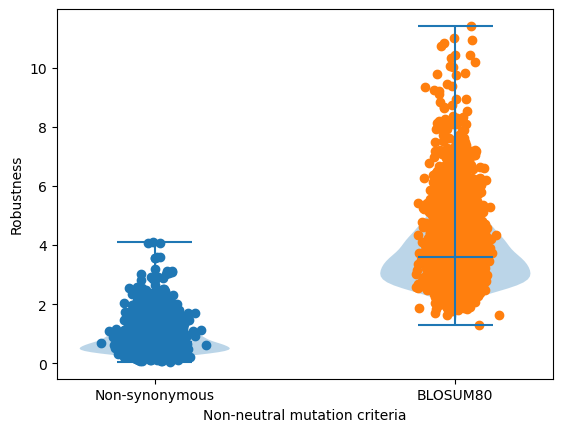

In [23]:
# 하나의 figure와 axis 생성
fig, ax = plt.subplots()

# ---- Violin Plot ----
# positions로 각각 x=1, x=2에 배치
ax.violinplot(data, positions=[1, 2], showmeans=False, showmedians=True)

# ---- Jitter Scatter ----
# 각 그룹 위치에 약간의 랜덤 노이즈를 주어 흩뿌리기
x1 = np.random.normal(1, 0.04, size=len(sbs2_lrho_ns))
x2 = np.random.normal(2, 0.04, size=len(lrhos))
ax.scatter(x1, sbs2_lrho_ns)
ax.scatter(x2, lrhos)

# 축 레이블 및 틱 설정, 타이틀 생략
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_xlabel('Non-neutral mutation criteria')
ax.set_ylabel('Robustness')

plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

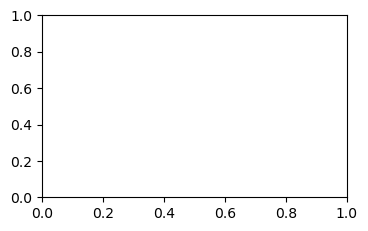

In [12]:
# Helper: cm → inch 변환 (1 inch = 2.54 cm)
def cm2inch(x):
    return x / 2.54

# 원하는 크기 (cm 단위)
width_cm, height_cm = 10, 6  # 예: 가로 10cm, 세로 6cm

# figsize에 인치 단위로 변환하여 전달
fig, ax = plt.subplots(figsize=(cm2inch(width_cm), cm2inch(height_cm)))

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

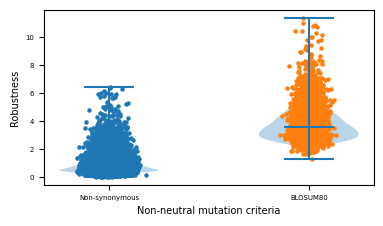

In [21]:
# 1) 전역 폰트를 Arial로 설정
plt.rc('font', family='Arial')

# 2) Figure 크기 지정 (inch 단위)
fig, ax = plt.subplots(figsize=(cm2inch(width_cm), cm2inch(height_cm)))

# 3) Violin plot
data = [sbs2_lrho_ns, lrhos]
positions = [1, 2]
ax.violinplot(data, positions=positions, showmeans=False, showmedians=True)

# 4) Jitter scatter (점 크기 s=10)
x1 = np.random.normal(positions[0], 0.04, size=len(sbs2_lrho_ns))
x2 = np.random.normal(positions[1], 0.04, size=len(lrhos))
ax.scatter(x1, sbs2_lrho_ns, s=5)
ax.scatter(x2, lrhos,         s=5)

# 5) 축 레이블 및 틱 폰트 사이즈
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=5)
ax.set_xlabel('Non-neutral mutation criteria', fontsize=7)
ax.set_ylabel('Robustness',                       fontsize=7)
ax.tick_params(axis='both', which='major', labelsize=5)

plt.tight_layout()

# 6) 파일로 저장
fig.savefig('/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/sbs2_partial.png', dpi=600)
fig.savefig('/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/sbs2_partial.svg')

plt.show()

In [14]:
import matplotlib.font_manager as fm

# ttf 리스트 중 이름에 'Arial' 이 포함된 폰트를 모두 뽑아 봅니다.
arial_list = [f for f in fm.fontManager.ttflist if 'arial' in f.name.lower()]

if arial_list:
    print("Found Arial fonts:")
    for f in arial_list:
        print(f"  - {f.name}  ({f.fname})")
else:
    print("Arial not found on this system.")

Arial not found on this system.


In [5]:
data_path = '/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Final_scripts/Simple_robustness_analysis_of_cds_files'
genes_fasta_file = Path(PurePath(data_path, "gencode.v40.pc_transcripts.nopary.cdsplus.fa"))

seq_records = list(SeqIO.parse(genes_fasta_file, "fasta"))

In [6]:
seq_record = seq_records[58042]

transcript_name = seq_record.id.split("|")[4]
seq = seq_record.seq

rhocom = snbr.RobustnessComputer(transcript_name, seq)
lrho = rhocom.compute_l_robustness(n_sim=1000, 
                                   method="signature", 
                                   eval_method="blosum", 
                                   mutational_signature='SBS2', 
                                   threshold = 20,
                                   multiprocessing=True)

In [7]:
import igraph as ig
import umap
from sklearn.manifold import TSNE

In [35]:
rhocom.trajs['lrho']['trajs'][0].get_records()[0].note

'.'

In [65]:
g = ig.Graph(directed=True)

for traj in rhocom.trajs['lrho']['trajs'][:2]: 
    records = traj.get_records()
    
    for rec in records:
        seq_str = str(rec.sequence)  # convert Seq to plain string
        if rec.note.startswith("score:"):
            # extract numeric part after "score:"
            try:
                val = float(rec.note.split("score:")[1])
            except ValueError:
                val = 0.0
        else:
            val = 0.0
        
        g.add_vertex(
            name=seq_str,
            hgvs_mrna=rec.hgvs_mrna,
            hgvs_aa=rec.hgvs_aa,
            mut_type=rec.mut_type,
            score=-1*val
        )
    
    for i in range(len(records) - 1):
        src_name = str(records[i].sequence)
        tgt_name = str(records[i+1].sequence)
        # find index with name
        src_idx = g.vs.find(name=src_name).index
        tgt_idx = g.vs.find(name=tgt_name).index
        g.add_edge(src_idx, tgt_idx)

In [90]:
str(rhocom.trajs['lrho']['trajs'][0].get_records()[0].sequence) == str(rhocom.trajs['lrho']['trajs'][0].get_records()[2].sequence) 

False

In [98]:
for traj in rhocom.trajs['lrho']['trajs'][:10]: 
    records = traj.get_records()
    for rec in records:
        print(rec)
    print("")

MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='.', hgvs_aa='.', mut_type='.', note='.')
MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.3430C>T', hgvs_aa='p.Q1144*', mut_type='T[C>T]A', note='score: 17.0')
MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.4756G>A', hgvs_aa='p.E1586K', mut_type='T[C>T]T', note='score: 24.0')

MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='.', hgvs_aa='.', mut_type='.', note='.')
MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.551C>T', hgvs_aa='p.S184F', mut_type='T[C>T]T', note='score: 11.0')
MutationRecord(sequence=Seq('AATGGATTTATCTGCTCTTCGCGTTGAAGAAGTACAAAATGTCATTAATGCTAT...GAC'), hgvs_mrna='c.715C>T', hgvs_aa='p.H239Y', mut_type='T[C>T]A', note='score: 20.0')

Mutation

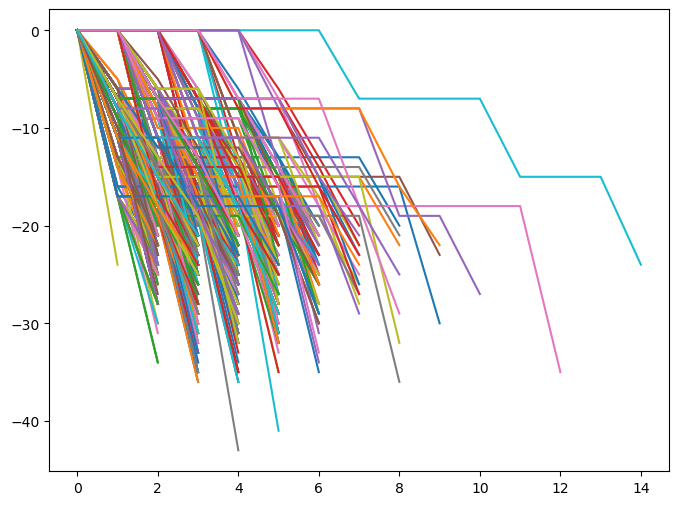

In [52]:
plt.figure(figsize=(8,6))

for traj in rhocom.trajs['lrho']['trajs']: 
    records = traj.get_records()
    xx = []
    yy = []
    for i, rec in enumerate(records):
        if rec.note.startswith("score:"):
            # extract numeric part after "score:"
            try:
                val = float(rec.note.split("score:")[1])
            except ValueError:
                val = 0.0
        else:
            val = 0.0
        xx.append(i)
        yy.append(-val)
    plt.plot(xx,yy)
plt.show()

In [53]:
out_degs = g.degree(mode="out")

# out_degree >= 2인 정점만 추출
nodes_with_many_out = [v for v, deg in zip(g.vs, out_degs) if deg >= 2]

# 정점의 인덱스 출력
print([v.index for v in nodes_with_many_out])

[0, 1, 9, 12, 16, 21, 27, 36, 40, 43, 49, 53, 58, 61, 74, 78, 80, 83, 86, 96, 101, 108, 113, 117, 122, 127, 133, 136, 142, 145, 153, 157, 160, 163, 167, 172, 176, 183, 186, 190, 193, 201, 205, 207, 214, 221, 227, 234, 237, 241, 243, 249, 256, 258, 265, 273, 278, 280, 300, 307, 324, 328, 341, 346, 350, 356, 358, 363, 368, 378, 384, 387, 390, 393, 401, 404, 410, 414, 432, 441, 448, 453, 458, 463, 473, 476, 480, 486, 491, 496, 512, 516, 519, 524, 531, 539, 555, 557, 560, 570, 575, 584, 588, 590, 592, 597, 600, 602, 605, 610, 617, 626, 632, 639, 648, 656, 676, 681, 684, 689, 718, 725, 729, 738, 748, 750, 765, 777, 781, 784, 791, 798, 802, 805, 823, 828, 830, 833, 837, 854, 864, 868, 871, 873, 881, 888, 891, 904, 912, 922, 937, 939, 946, 952, 955, 976, 980, 992, 998, 1003, 1010, 1014, 1019, 1030, 1063, 1071, 1076, 1077, 1085, 1090, 1092, 1114, 1135, 1144, 1149, 1168, 1178, 1188, 1195, 1218, 1228, 1236, 1250, 1253, 1257, 1270, 1276, 1290, 1294, 1299, 1303, 1316, 1330, 1348, 1363, 1367, 1401,

In [8]:
cosmic_file = "/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/cosmic_signatures/COSMIC_v3.3.1_SBS_GRCh38.txt"
cosmic_probs = pd.read_csv(cosmic_file, sep= "\t", header=0).set_index('Type', drop=False)
# sbs2_probs = 

In [120]:
cosmic_probs.at['T[C>T]A','SBS2']

0.535130188298692

In [38]:
g = ig.Graph(directed=True)

# A: 전체 트래젝토리에 걸쳐 하나의 매핑을 유지
seq_to_idx = {}

for traj in rhocom.trajs['lrho']['trajs']: 
    records = traj.get_records()
    
    # B’: vertex 추가 시 중복 방지하고 인덱스 저장
    for rec in records:
        seq_str = str(rec.sequence)
        if seq_str not in seq_to_idx:
            if rec.note.startswith("score:"):
                # extract numeric part after "score:"
                try:
                    val = float(rec.note.split("score:")[1])
                except ValueError:
                    val = 0.0
            else:
                val = 0.0
            # create a new vertex and remember its index
            g.add_vertex(
                name=seq_str,
                hgvs_mrna=rec.hgvs_mrna,
                hgvs_aa=rec.hgvs_aa,
                mut_type=rec.mut_type,
                score= -1*val,
                nmuts = 0
            )
            seq_to_idx[seq_str] = g.vcount() - 1

    # C’: 저장해 둔 인덱스만 꺼내서 edge 추가
    for i in range(len(records) - 1):
        src_name = str(records[i].sequence)
        tgt_name = str(records[i+1].sequence)
        src_idx = seq_to_idx[src_name]
        tgt_idx = seq_to_idx[tgt_name]
        g.vs[src_idx]['nmuts'] = i
        g.vs[tgt_idx]['nmuts'] = i+1
        
        prob = cosmic_probs.at[records[i+1].mut_type,'SBS2']
        g.add_edge(src_idx, tgt_idx, prob=1-prob, dist=1)

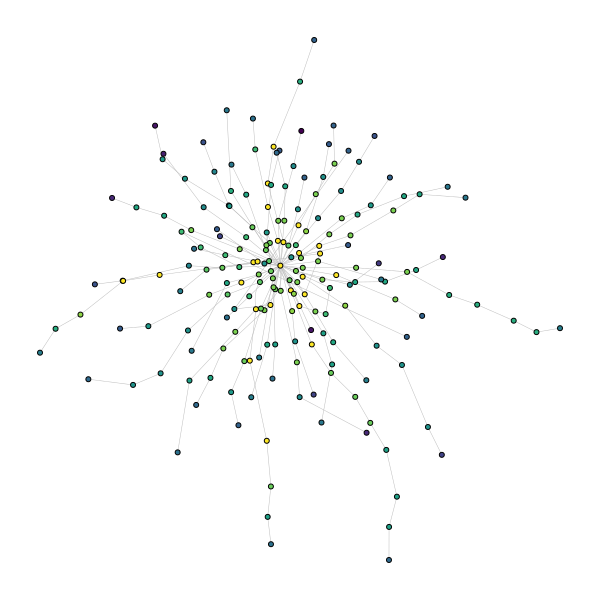

In [37]:
import numpy as np
import igraph as ig
from igraph import plot
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 0) score → 0~1 정규화 (컬러맵용)
scores = np.array(g.vs['score'], dtype=float)
norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

# 컬러맵에서 RGBA → HEX
cmap = cm.get_cmap('viridis')
vertex_colors = [mcolors.to_hex(cmap(x)) for x in norm_scores]

# 1) prob 을 “거리”로 쓰는 Kamada–Kawai 레이아웃
#    weights 인자가 곧 엣지 간 목표 거리가 됩니다.
layout = g.layout_kamada_kawai(weights=g.es['prob'])

# 2) 그리기
plot(
    g,
    layout=layout,
    vertex_color=vertex_colors,
    vertex_size=5,
    vertex_label=None,      # 레이블이 필요하면 g.vs['name'] 등 지정
    edge_width=0.5,
    edge_arrow_size=0.1, 
    edge_color='gray',
    margin=40,
    bbox=(600, 600)
)

In [65]:
import numpy as np
import igraph as ig
from igraph import plot
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 0) score → 0~1 정규화 (컬러맵용)
scores = np.array(g.vs['score'], dtype=float)
norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

# 컬러맵에서 RGBA → HEX
cmap = cm.get_cmap('viridis')
vertex_colors = [mcolors.to_hex(cmap(x)) for x in norm_scores]

layout = g.layout_reingold_tilford()

plot(
    g,
    layout=layout,
    vertex_color=vertex_colors,
    vertex_size=3,
    vertex_label=None,
    edge_width=0.5,
    edge_arrow_size=0.1,
    vertex_frame_width=0.1,
    edge_color='gray',
    margin=40,
    bbox=(1000, 1000)
)



In [50]:
import numpy as np
import igraph as ig
from igraph import plot
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 0) score → 0~1 정규화 (컬러맵용)
scores = np.array(g.vs['score'], dtype=float)
norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

# 컬러맵에서 RGBA → HEX
cmap = cm.get_cmap('viridis')
vertex_colors = [mcolors.to_hex(cmap(x)) for x in norm_scores]

# 1) prob 을 “거리”로 쓰는 Kamada–Kawai 레이아웃
#    weights 인자가 곧 엣지 간 목표 거리가 됩니다.
layout = g.layout_kamada_kawai(weights=g.es['dist'])

# 2) 그리기
plot(
    g,
    layout=layout,
    vertex_color=vertex_colors,
    vertex_size=4,
    vertex_label=None,      # 레이블이 필요하면 g.vs['name'] 등 지정
    edge_width=0.5,
    edge_arrow_size=0.1, 
    vertex_frame_width=0.2,
    edge_color='gray',
    margin=40,
    bbox=(600, 600),
    target="/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/brca-1_sbs2.svg"
)

# 2) 그리기
plot(
    g,
    layout=layout,
    vertex_color=vertex_colors,
    vertex_size=50,
    vertex_label=None,      # 레이블이 필요하면 g.vs['name'] 등 지정
    edge_width=2,
    edge_arrow_size=0.3, 
    vertex_frame_width=1,
    edge_color='gray',
    margin=40,
    bbox=(3600, 3600),
    target="/mnt/c/Users/CEEL-PC-005/Desktop/Joon/Package_development_deck/sinabro/test/tmp/brca-1_sbs2.png"
)

In [44]:
# 1) Parse score values from g.vs["note"]; "."이면 0으로
scores = np.array(g.vs["score"])

# 2) Compute all-pairs shortest-path distances (edge weight = 1)
dist_matrix = np.array(g.shortest_paths_dijkstra())

#    inf는 연결 안 된 노드; 최댓값 * 1.5로 대체
finite = dist_matrix[np.isfinite(dist_matrix)]
maxd = finite.max() if finite.size else 1.0
dist_matrix[~np.isfinite(dist_matrix)] = maxd * 1.5

# 3) t-SNE embedding with precomputed distances
tsne = TSNE(
    n_components=2,       # 2D embedding
    metric="precomputed", # 이미 계산된 거리 행렬 사용
    perplexity=5,         # 국소성 조절 (노드 개수에 맞춰 조정)
    random_state=42
)
coords = tsne.fit_transform(dist_matrix)  # shape = (n_nodes, 2)

# 3) Grid 생성: x, y 범위를 50x50 격자로 분할
x_min, x_max = coords[:,0].min(), coords[:,0].max()
y_min, y_max = coords[:,1].min(), coords[:,1].max()
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 50),
    np.linspace(y_min, y_max, 50)
)

/tmp/ipykernel_17273/2916511376.py:5: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  dist_matrix = np.array(g.shortest_paths_dijkstra())
/home/ceel/miniconda3/envs/seta_demo/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:691: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  warnings.warn(


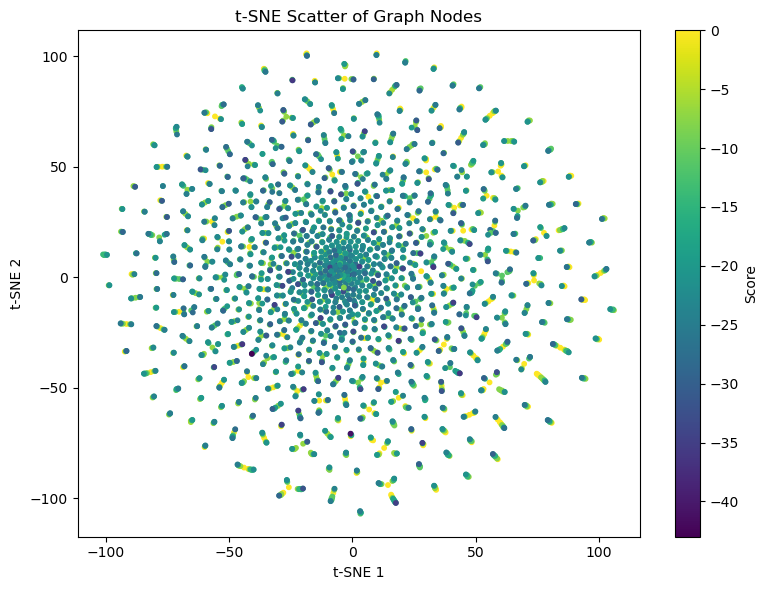

In [45]:
# 1) t-SNE scatter plot
plt.figure(figsize=(8,6))
# 점 색을 score 값에 따라 표현하고 싶다면 cmap 사용
sc = plt.scatter(
    coords[:,0], coords[:,1],
    c=scores,            # score 로 색상 매핑
    cmap='viridis',      # colormap (원하시는 것으로 변경 가능)
    s=10                 # marker size
)
plt.colorbar(sc, label='Score')  # 컬러바 추가

# 3) 축 및 제목 설정
plt.title("t-SNE Scatter of Graph Nodes")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

In [47]:
np.min(scores)

-50.0

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

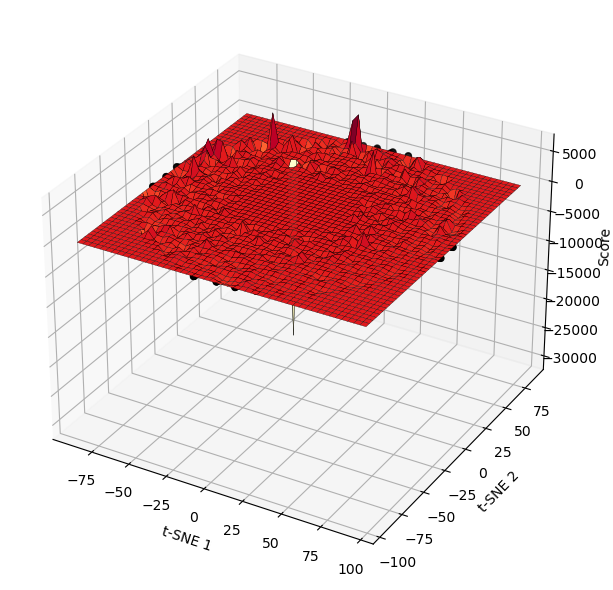

In [57]:
# 4) 불규칙한 (x,y)->score 데이터를 그리드로 보간
grid_z = griddata(
    points=(coords[:,0], coords[:,1]),  # original data points
    values=scores,                      # original z values
    xi=(grid_x, grid_y),                # target grid
    method='cubic',                     # 'linear', 'nearest' 도 가능
    fill_value=0#np.min(scores)                      # 보간 불가 구역은 0으로
)

# 5) 3D surface 그리기
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Triangulation 대신 plot_surface 사용
ax.plot_surface(
    grid_x, grid_y, grid_z,
    linewidth=0.2,
    antialiased=True, cmap='YlOrRd', edgecolor='black'
)

# 원본 노드 위치에 점 찍기
ax.scatter(coords[:,0], coords[:,1], scores, color='black', s=20)

# 축 레이블
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("Score")

plt.tight_layout()
plt.show()